<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Pertemuan1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Accessing My Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


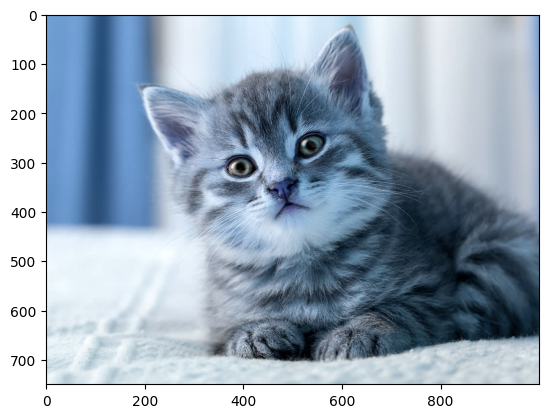

In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('/content/drive/MyDrive/asset/Kitten.jpg')
plt.imshow(img)

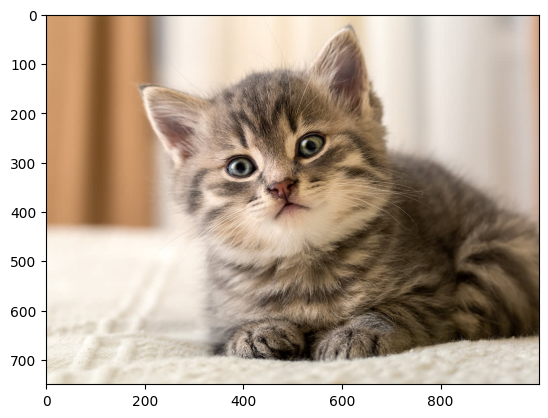

In [ ]:
img2 = img
img3 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img3)

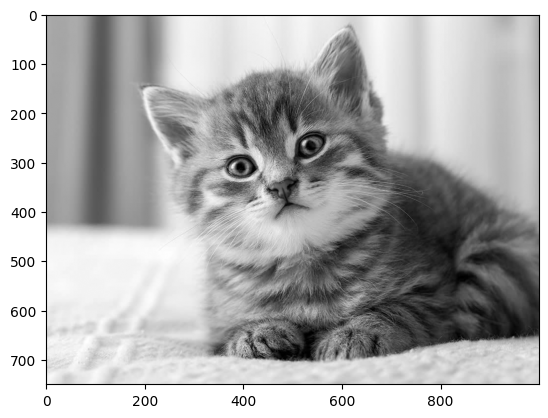

In [ ]:
img_gray = cv.imread('/content/drive/MyDrive/asset/Kitten.jpg', cv.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap='gray')

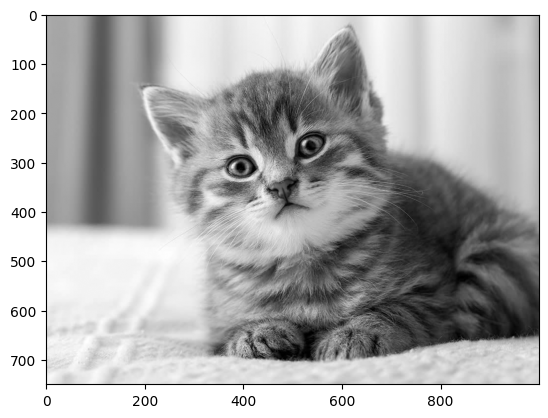

In [ ]:
plt.imshow(img_gray, cmap='gray')

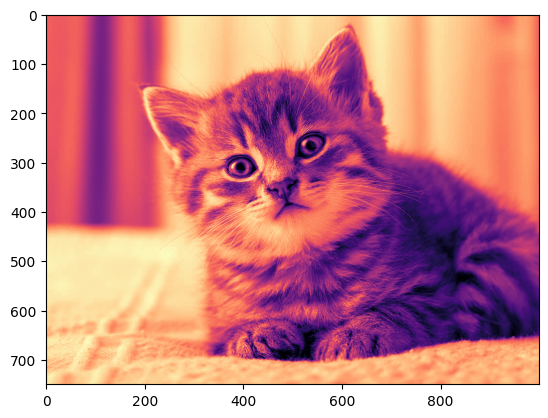

In [ ]:
plt.imshow(img_gray, cmap='magma')

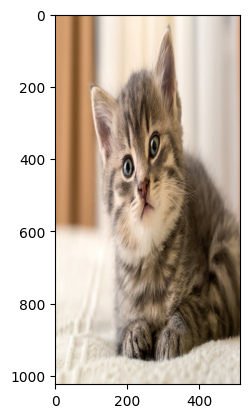

In [ ]:
img4 = cv.resize(cv.cvtColor(img,cv.COLOR_BGR2RGB), (512,1024))
plt.imshow(img4)

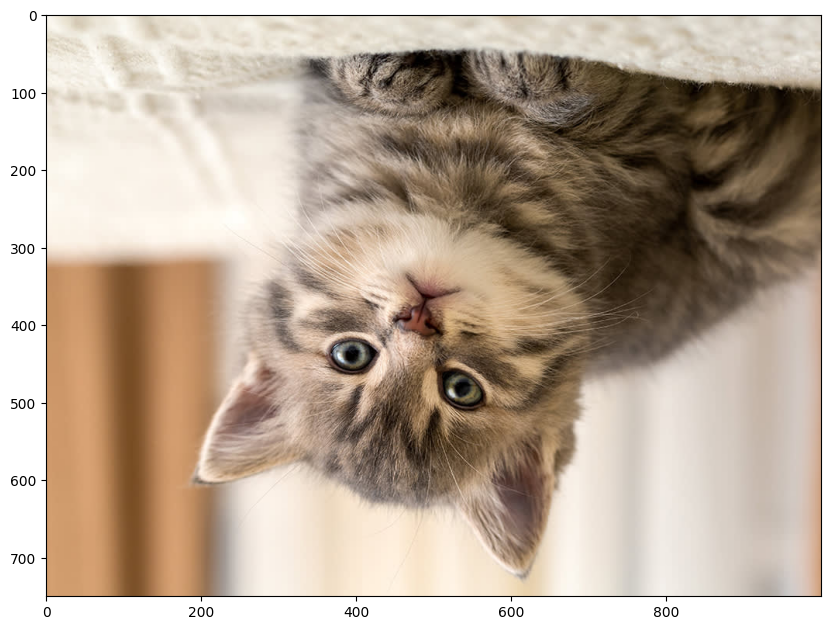

In [ ]:
img5 = cv.flip(cv.cvtColor(img,cv.COLOR_BGR2RGB), 0)

#simpan file image
#cv.imwrite('/content/drive/MyDrive/asset/Kitten2.jpg', img5)

#tampilkan plot dengan ukuran canvas yg lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.imshow(img5)

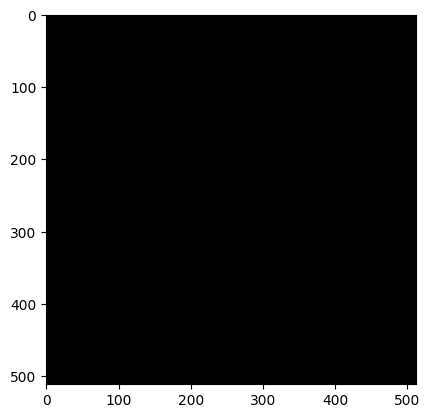

In [ ]:
black_img = np.zeros(shape=(512,512,3), dtype=np.int16)
plt.imshow(black_img)

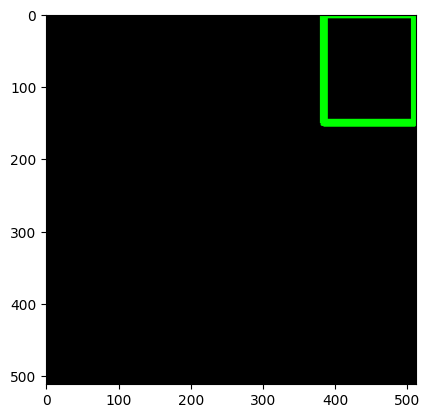

In [ ]:
# Koordinat titik pt1 dan pt2
cv.rectangle(black_img, pt1=(384,0), pt2=(510,150), color=(0,255,0), thickness=10)
plt.imshow(black_img)

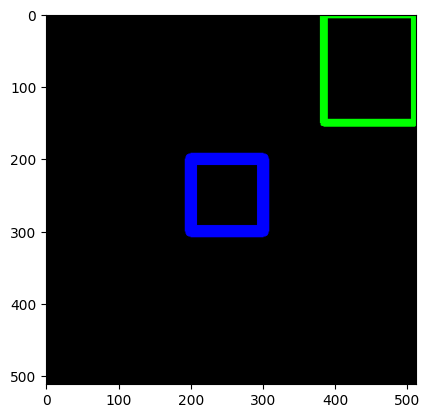

In [ ]:
cv.rectangle(black_img, pt1=(200,200), pt2=(300,300), color=(0,0,255), thickness=15)
plt.imshow(black_img)

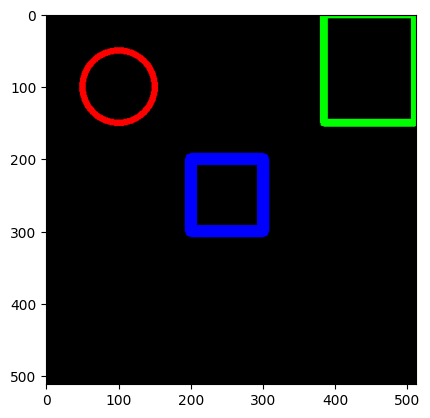

In [ ]:
cv.circle(black_img, center=(100,100), radius=50, color=(255,0,0), thickness=8)
plt.imshow(black_img)

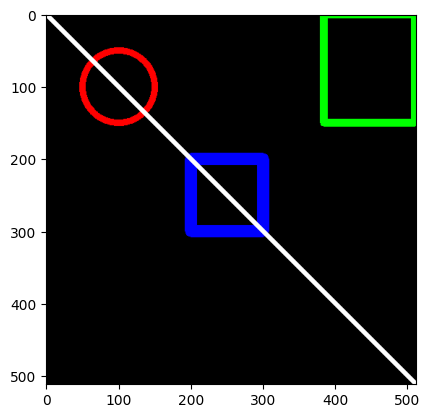

In [ ]:
cv.line(black_img, pt1=(0,0), pt2=(512,512), color=(255,255,255), thickness=5)
plt.imshow(black_img)

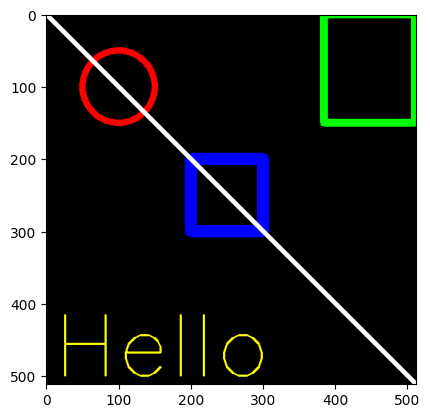

In [ ]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10,500), fontFace=font, fontScale=4, color=(255,255,0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

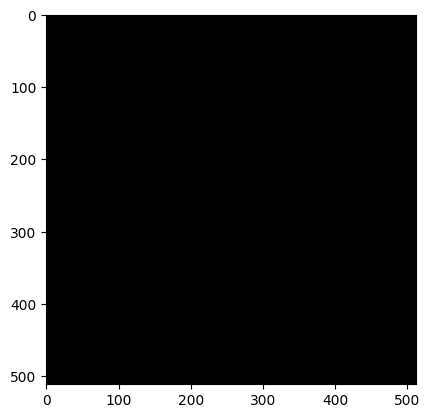

In [ ]:
black_img2 = np.zeros(shape=((512,512,3)), dtype=np.int32)
plt.imshow(black_img2)

In [ ]:
vertices = np.array(
    [
        [100,300],
        [200,200],
        [400,300],
        [200,400]
    ],
    dtype=np.int32
)
vertices

array([[100, 300],
       [200, 200],
       [400, 300],
       [200, 400]], dtype=int32)

In [ ]:
pts = vertices.reshape((-1,1,2))
pts

array([[[100, 300]],

       [[200, 200]],

       [[400, 300]],

       [[200, 400]]], dtype=int32)

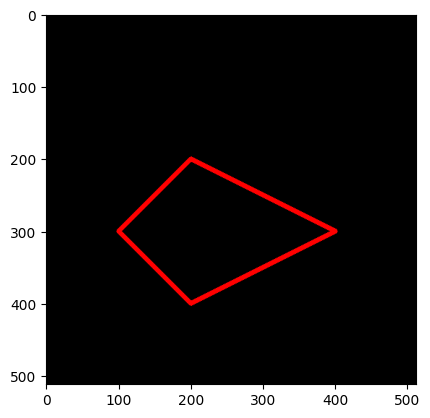

In [ ]:
cv.polylines(black_img2, [pts], isClosed=True, color=(255,0,0), thickness=5)
plt.imshow(black_img2)

## Pertanyaan Praktikum D3
1. Apakah perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib?
2. Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data int16 dan int32?
3. Apakah kegunaan “google.colab.patches import cv2_imshow” pada potongan
kode berikut
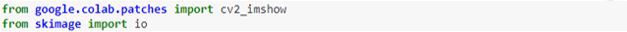
4. Apakah kegunaan “skimage import io” pada potongan kode soal nomor 3

### Jawaban Pertanyaan Praktikum D3
1. Matplotlib memberikan garis x dan y yang berfungsi untuk memetakan koordinat untuk tiap piksel pada gambar. Tanpa matplotlib, skala tersebut tidak akan muncul
2. Black image dengan int32 memiliki nilai rentang yang lebih besar daripada int16. Hal ini akan memengaruhi memori yang digunakan untuk menampilkan black image.
3. Untuk menggantikan fungsi asli dari cv2 yaitu cv.imshow yang kurang kompatibel jika digunakan pada google colab
4. Melakukan import untuk library io pada skimage yang kemudian dapat digunakan untuk melakukan operasi input output gambar

## Tugas Praktikum D3

1. Dengan menggunakan figsize, perhatikan apakah ukuran image pixelnya
juga berubah?
- Ukuran piksel pada gambar tidak berubah. Hanya ukuran kanvas untuk menampilkan gambar tersebut

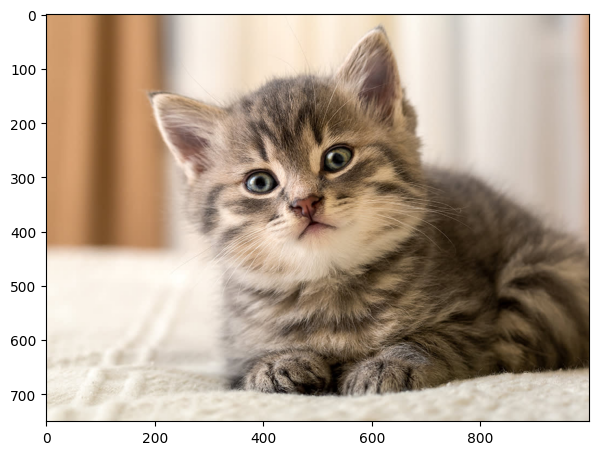

In [ ]:
fig = plt.figure(figsize=(7,10))
ax = fig.add_subplot(111)
ax.imshow(img3)

2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja!

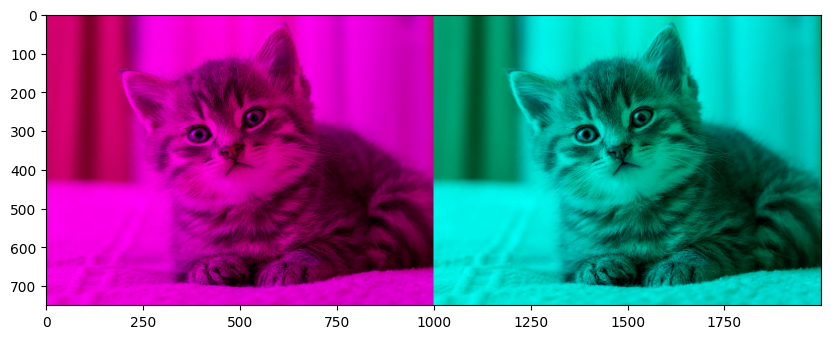

In [ ]:
B, G, R = cv.split(img)

red_blue = np.zeros_like(img)
red_blue[:,:,0] = B   # Blue
red_blue[:,:,2] = R   # Red

green_blue = np.zeros_like(img)
green_blue[:,:,0] = B   # Blue
green_blue[:,:,1] = G   # Green

img_RB = cv.cvtColor(red_blue, cv.COLOR_BGR2RGB)
img_GB = cv.cvtColor(green_blue, cv.COLOR_BGR2RGB)

final_frame = cv.hconcat((img_RB, img_GB))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.imshow(final_frame)

3. Tampilkan image baris ke 20-115, kolom 25-120!

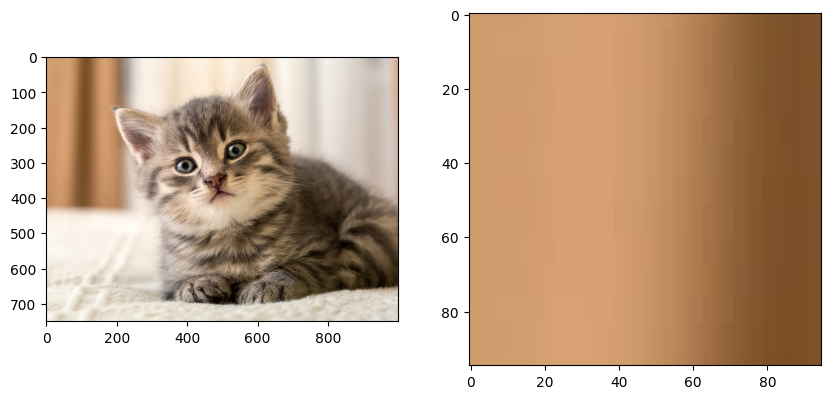

In [ ]:
image = cv.cvtColor(img, cv.COLOR_BGR2RGB)
image_result = np.zeros(shape=((115-20,120-25,3)), dtype=np.uint8)
x_out = y_out = 0
for y in range(25, 120):
  for x in range(20, 115):
    image_result[x_out, y_out] = image[x, y]
    x_out += 1
  x_out = 0
  y_out += 1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)

plt.subplot(1,2,2)
plt.imshow(image_result)

4. Tampilkan image baris ke 5-30, semua kolom, channel Red saja!

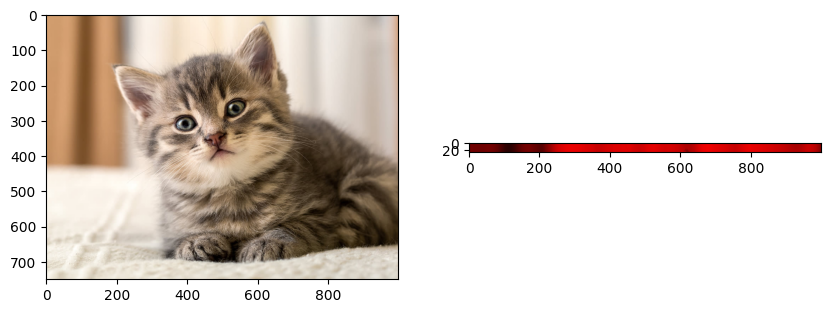

In [ ]:
tinggi = image.shape[0]
lebar = image.shape[1]
image_result = np.zeros(shape=((30-5,lebar,3)), dtype=np.uint8)

B, G, R = cv.split(image)

red_image = np.zeros_like(image)
red_image[:,:,2] = R   # Red

img_R = cv.cvtColor(red_image, cv.COLOR_BGR2RGB)

x_out = y_out = 0
for y in range(lebar):
  for x in range(5, 30):
    image_result[x_out, y_out] = img_R[x, y]
    x_out += 1
  x_out = 0
  y_out += 1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)

plt.subplot(1,2,2)
plt.imshow(image_result)

5. Buat 5 kotak berbagai ukuran dan warna yang berbeda dalam satu image.
disarankan menggunakan bilangan acak/random!

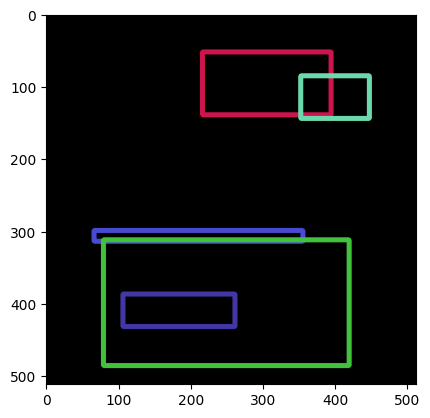

In [ ]:
from random import randint

black_img = np.zeros(shape=(512,512,3), dtype=np.uint8)

for i in range(5):
  xy1 = (randint(0, 512), randint(0, 512))
  xy2 = (randint(0, 512), randint(0, 512))
  rgb = (randint(0, 255), randint(0, 255), randint(0, 255))
  cv.rectangle(black_img, pt1=xy1, pt2=xy2, color=rgb, thickness=5)

plt.imshow(black_img)

6. Tampilkan image dengan posisi terbalik!

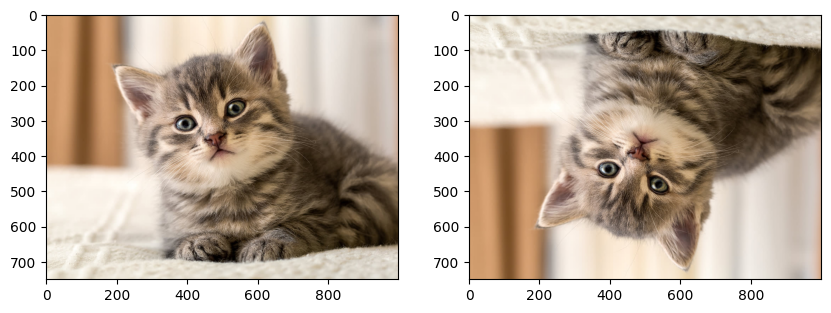

In [ ]:
img_flip = cv.flip(cv.cvtColor(img,cv.COLOR_BGR2RGB), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img3)

plt.subplot(1,2,2)
plt.imshow(img_flip)

7. Buat rectangle dan circle pada bagian wajah dari image foto s anda saat
beraktifitas (bukan pasfoto).

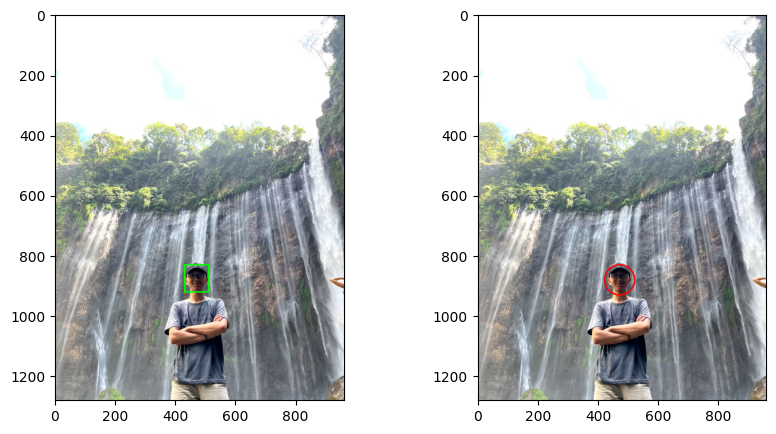

In [ ]:
url = cv.imread('/content/drive/MyDrive/asset/aktifitas.jpg')
img_activity = cv.cvtColor(url, cv.COLOR_BGR2RGB)
act_square = img_activity.copy()
act_circle = img_activity.copy()

cv.rectangle(act_square, pt1=(430,830), pt2=(510,920), color=(0,255,0), thickness=3)
cv.circle(act_circle, center=(470,880), radius=50, color=(255,0,0), thickness=3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(act_square)

plt.subplot(1,2,2)
plt.imshow(act_circle)

8. Buat rectangle pada bagian sudut bawah kiri channel B pada color space
RGB dari citra kitten/ lena/ mandrill/ male/ female/ couple/ sailboat/
peppers!

9. Lengkapi tulisan nama file pada file citra dari soal no.8. gunakan font,
ukuran font, dan warna font yang sesuai keinginan anda.

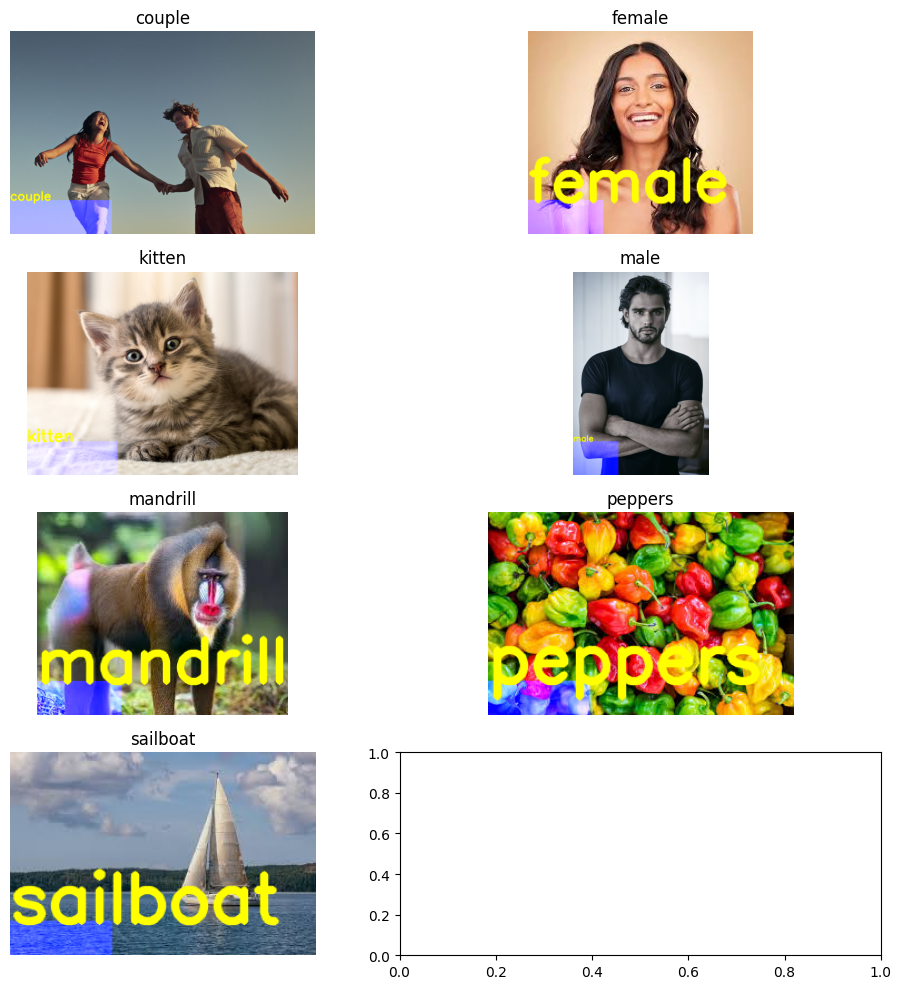

In [ ]:
urls = [
    ["couple", "/content/drive/MyDrive/asset/Couple.jpg"],
    ["female", "/content/drive/MyDrive/asset/Female.jpeg"],
    ["kitten", "/content/drive/MyDrive/asset/Kitten.jpg"],
    ["male", "/content/drive/MyDrive/asset/Male.jpg"],
    ["mandrill", "/content/drive/MyDrive/asset/Mandrill.jpeg"],
    ["peppers", "/content/drive/MyDrive/asset/Peppers.jpeg"],
    ["sailboat", "/content/drive/MyDrive/asset/Sailboat.jpeg"],
]

img = {}

for name, path in urls:
  url = cv.imread(path)

  rgb = cv.cvtColor(url, cv.COLOR_BGR2RGB)

  R, G, B = cv.split(rgb)

  tinggi, lebar = B.shape
  xy1 = (0, int(tinggi*5/6))
  xy2 = (int(lebar*1/3), tinggi-1)

  cv.rectangle(B, pt1=xy1, pt2=xy2, color=255, thickness=-1)

  merged = cv.merge([R, G, B])
  cv.putText(merged, text=name, org=xy1, fontFace=font, fontScale=2, color=(255,255,0), thickness=5, lineType=cv.LINE_AA)
  img[name] = merged

fig, axes = plt.subplots(4,2, figsize=(10,10))
axes = axes.flatten()
for ax, (name, image) in zip(axes, img.items()):
  ax.imshow(image)
  ax.set_title(name)
  ax.axis("off")

plt.tight_layout()
plt.show()

1. Akses file image lokal (KTM) dan tampilkan menggunakan OpenCV dan
Matplotlib

2. Tutup tiap bagian tertentu dari KTM tersebut menggunakan fungsi yang telah
Anda pelajari. Kreasikan terkait dengan warna dan ukuran dari bentuk
bentuknya.

  Kelompok 6 logo Polinema dan tulisan POLINEMA

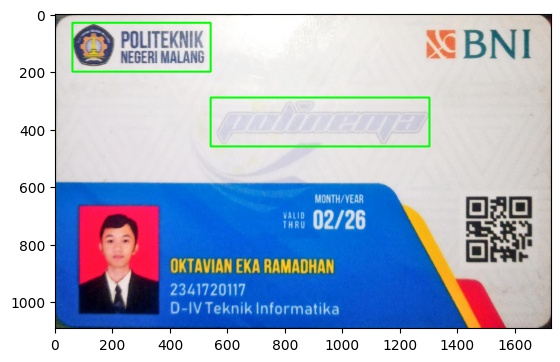

In [30]:
url = "/content/drive/MyDrive/asset/KTM.jpg"
ktm_bgr = cv.imread(url)
img_ktm = cv.cvtColor(ktm_bgr, cv.COLOR_BGR2RGB)

cv.rectangle(img_ktm, pt1=(60,30), pt2=(540,200), color=(0,255,0), thickness=5)
cv.rectangle(img_ktm, pt1=(540,290), pt2=(1300,460), color=(0,255,0), thickness=5)

plt.imshow(img_ktm)